# CAPEC Dataset and Its Re-exploration in the UCKG Project

- Name: Sonpaorong (Rong) Muchhim
- Email: smuchhim@angelo.edu or muchhim.sonpaorong@gmail.com

## ** Important Note: Only Running Qureies After Exploration Part **
- Due some quries were being run at different Neo4j before changes, thus, if it were to Re-run, it will produces the same Before-After.

- Exception -> Project Setup Query

## Project Description

The Common Attack Pattern Enumeration and Classification (CAPEC) dataset, maintained by MITRE, is a publicly available catalog that documents common attack patterns used by adversaries to exploit weaknesses in applications and cyber-enabled systems. These "Attack Patterns" serve as structured descriptions of the techniques, behaviors, and strategies employed during an attack. CAPEC entries are derived from detailed analyses of real-world incidents and include vital information such as:

- CAPEC_ID (can be reference back to source)
- Name
- Abstraction detail
- Description
- Likelihood of Attack
- Severity
- Related Attack Patterns (CAPEC to CAPEC)
- Execution Flow (techniques)
- Prerequisites
- Skills Require
- Resources Require
- Consequences
- Mitigation Strategies
- Example Instance
- Related Weaknesses (CAPEC to CWE) 
and mappings to related MITRE Attack.

CAPEC is organized using multiple hierarchical taxonomies, allowing users to explore patterns by **Mechanisms of Attack**—focusing on the tactics employed—or by **Domains of Attack**, emphasizing the targets. This structure supports a range of cybersecurity tasks including threat modeling, application security assessments, red teaming, and incident response planning.

As part of the Unified Cybersecurity Knowledge Graph (UCKG) project, we re-explore and integrate CAPEC data to establish semantically rich relationships across multiple cybersecurity knowledge domains. By mapping CAPEC patterns to related entities such as CWEs and MITRE ATT&CK techniques, the UCKG enables a unified, queryable structure that enhances understanding of how adversarial behaviors align with known weaknesses and real-world vulnerabilities. This re-exploration supports advanced threat analysis, automation of security assessments, and the development of intelligent defense strategies across the cyber threat landscape.

## Project Setup

In [1]:
from neo4j import GraphDatabase
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

uri = "bolt://localhost:7687"
username = "neo4j"
password = "abcd90909090"

driver = GraphDatabase.driver(uri, auth=(username, password))

def run_query(query, parameters=None):
    with driver.session() as session:
        result = session.run(query, parameters)
        return [record.data() for record in result]

============================================================================================

In [3]:
query_db = """
   Call db.schema.visualization()
"""
params = {}
records = run_query(query_db, parameters=params)
df_db = pd.DataFrame(records)
df_db

,nodes,relationships
0,"[{'name': 'ObjectProperty', 'indexes': [], 'co...","[({'name': 'UcoCVE', 'indexes': [], 'constrain..."


![Neo4j db.schema visualization.png](<attachment:Neo4j db.schema visualization.png>)
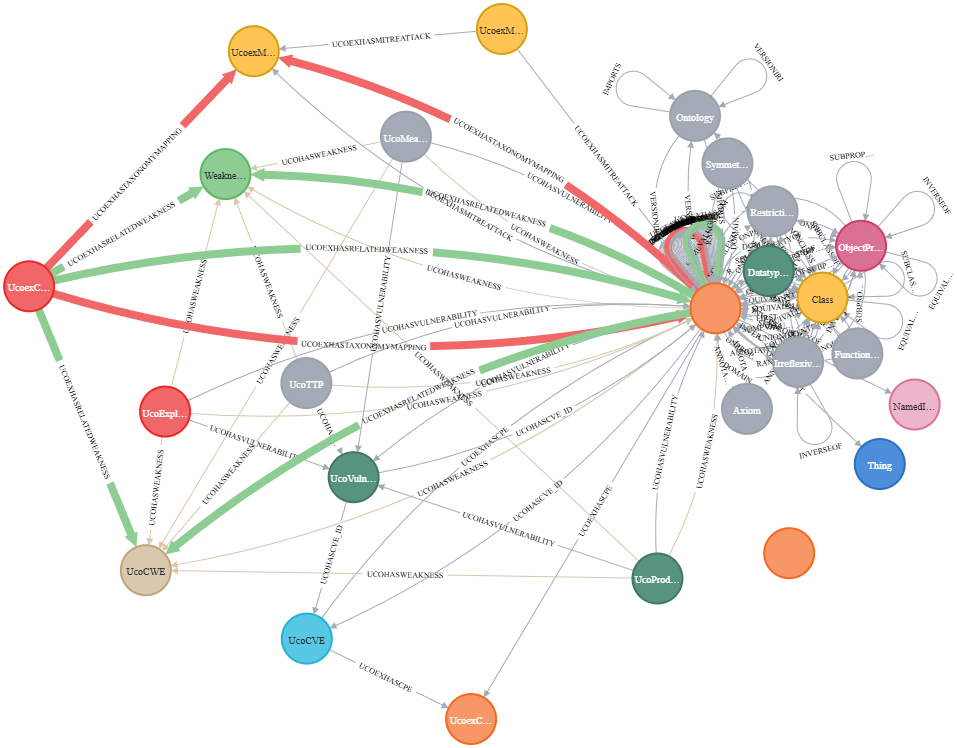

In [ ]:
# Cypher query to pull only Node labeled "UcoexCAPEC", recording 177 Nodes count
query = """
MATCH (n:UcoexCAPEC) RETURN id(n) AS CAPEC_Node_Id, labels(n) AS Node_Labels_AS, properties(n) AS NodeProperties
"""
params = {}
records = run_query(query, parameters=params)
df = pd.DataFrame(records)
df

,CAPEC_Node_Id,Node_Labels_AS,NodeProperties
0,713882,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-2'}
1,713883,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-1'}
2,713957,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-593'}
3,713959,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-573'}
4,713960,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-572'}
...,...,...,...
172,714265,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-203'}
173,714266,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-204'}
174,714267,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-206'}
175,714268,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-300'}


In [ ]:
# Spliting uri string for CAPEC_ID only for referencing missing CAPEC from source
df['CAPEC_ID'] = df['NodeProperties'].apply(lambda x: x['uri'].split('#')[-1])
df
# Explaination of the code above:
# The CAPEC_Id is necessary if the intention is to recheck the missing nodes from dataset (dataset of CAPEC soruce: https://capec.mitre.org/data/downloads.html)
# Notice: The node in UCKG has only 177 nodes where through CSV datasets both from Mechanism of Att and Domains of Att have total of unique CAPEC_Id
# Some missing node of CAPEC

,CAPEC_Node_Id,Node_Labels_AS,NodeProperties,CAPEC_ID
0,713882,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-2'},CAPEC-2
1,713883,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-1'},CAPEC-1
2,713957,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-593'},CAPEC-593
3,713959,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-573'},CAPEC-573
4,713960,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-572'},CAPEC-572
...,...,...,...,...
172,714265,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-203'},CAPEC-203
173,714266,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-204'},CAPEC-204
174,714267,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-206'},CAPEC-206
175,714268,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-300'},CAPEC-300


In [ ]:
# Cypher Query the node from UcoexCAPEC connected to UcoexMITREATTACK (aka: Att Tactic, Technique, Common Knowledge)
query1 = """
MATCH (c:UcoexCAPEC)-[r]->(p:UcoexMITREATTACK) RETURN id(c) AS CAPEC_Node, labels(c) AS CAPEC_label, properties(c) AS CAPEC_uri,
type(r) AS Relationship, id(p) AS ATT_CK_Id, labels(p) AS ATT_CK_label, properties(p) AS ATT_CK_uri
"""
params = {}
records = run_query(query1, parameters=params)
df1 = pd.DataFrame(records)
df1
# Understanding: Through the dataset, if from initial CAPEC do not have TAXONOMY, the relationship in UCKG seemingly do not have connection

,CAPEC_Node,CAPEC_label,CAPEC_uri,Relationship,ATT_CK_Id,ATT_CK_label,ATT_CK_uri
0,713882,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-2'},UCOEXHASTAXONOMYMAPPING,714123,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1531'}
1,713883,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASTAXONOMYMAPPING,713903,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1574.010'}
2,713957,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-593'},UCOEXHASTAXONOMYMAPPING,714117,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1563'}
3,713957,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-593'},UCOEXHASTAXONOMYMAPPING,713884,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1185'}
4,713957,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-593'},UCOEXHASTAXONOMYMAPPING,714207,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1550.001'}
...,...,...,...,...,...,...,...
272,714267,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-206'},UCOEXHASTAXONOMYMAPPING,714105,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1553.002'}
273,714268,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-300'},UCOEXHASTAXONOMYMAPPING,713938,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1046'}
274,714269,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-309'},UCOEXHASTAXONOMYMAPPING,713951,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1016'}
275,714269,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-309'},UCOEXHASTAXONOMYMAPPING,714138,"[Resource, UcoexMITREATTACK]",{'uri': 'http://example.com/ucoex#1590'}


Red Node: CAPEC, Yellow Node: MITRE ATT&CK

![UcoexCAPEC to UcoexMITREATTACK.png](<attachment:UcoexCAPEC to UcoexMITREATTACK.png>)
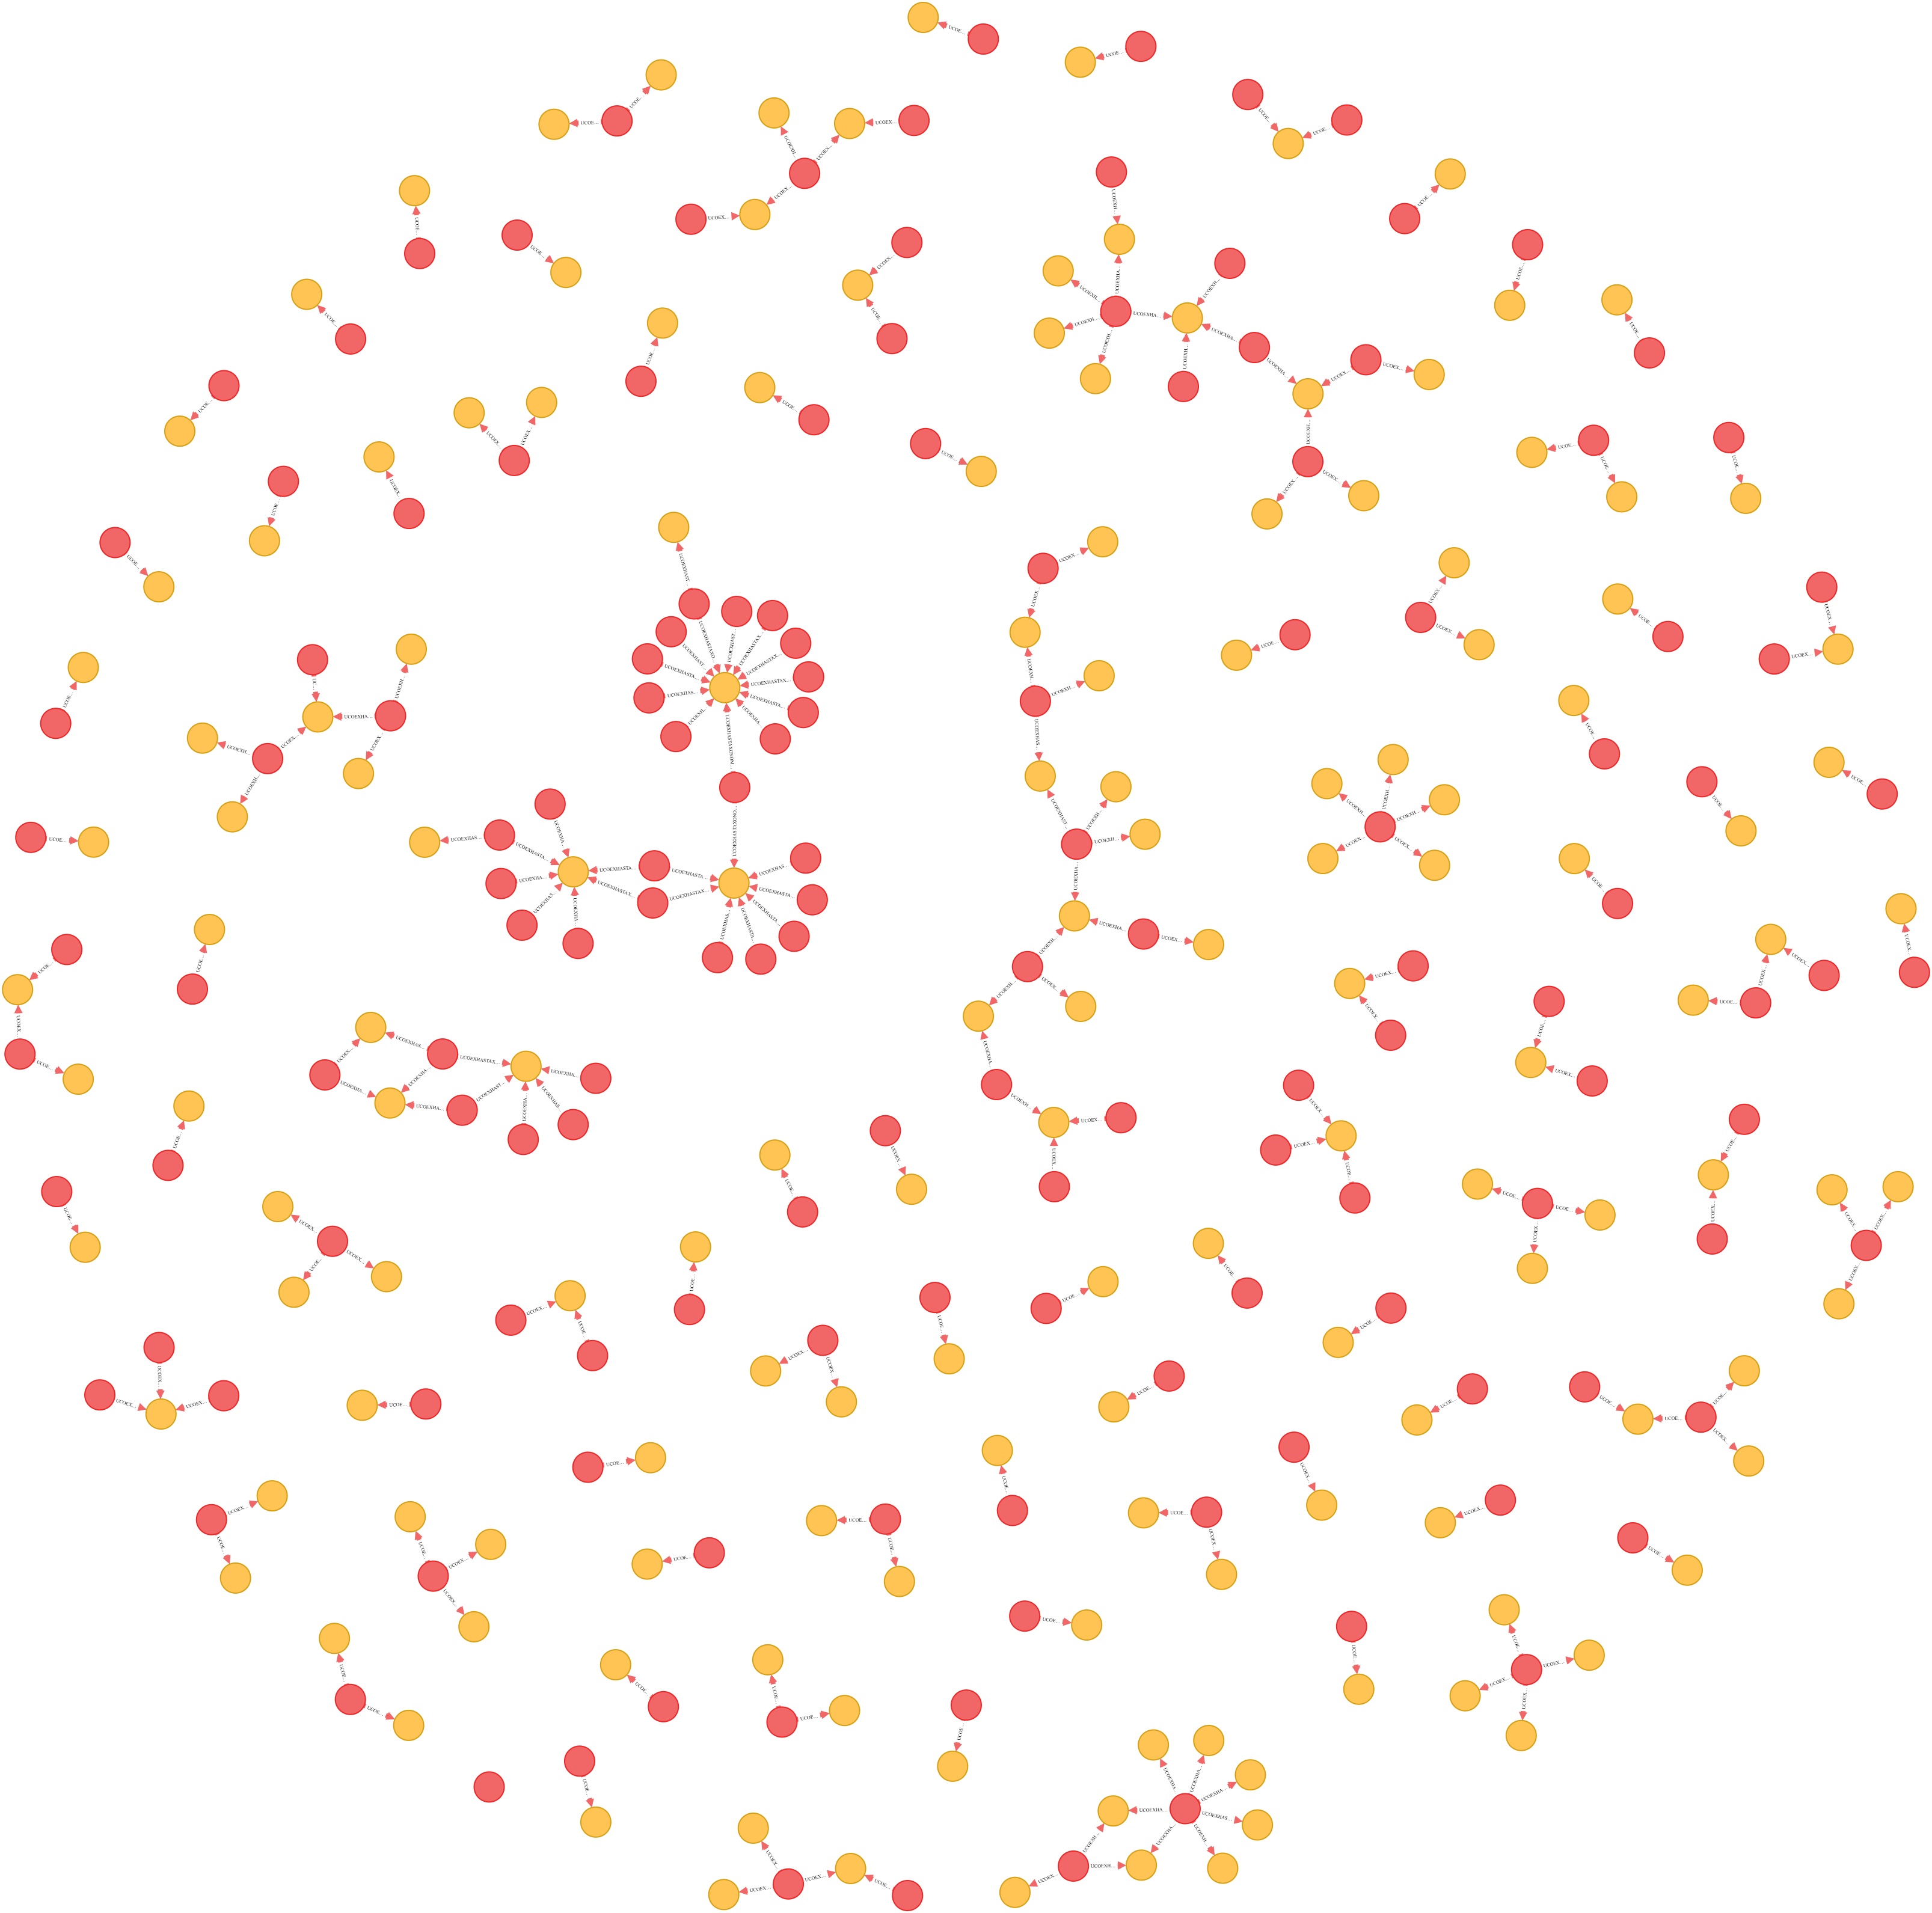

In [ ]:
# Cypher Query the node from UcoexCAPEC that has relationship "related weakness" to other node, mostly about CWE
query2 = """
MATCH (c:UcoexCAPEC)-[r:UCOEXHASRELATEDWEAKNESS]->(p:Resource) RETURN id(c) AS CAPEC_Node, labels(c) AS CAPEC_label, properties(c) AS CAPEC_uri,
type(r) AS Relationship, id(p) AS Other_Node, labels(p) AS Node_label, properties(p) AS Node_Details
"""
params = {}
records = run_query(query2, parameters=params)
df2 = pd.DataFrame(records)
df2

,CAPEC_Node,CAPEC_label,CAPEC_uri,Relationship,Other_Node,Node_label,Node_Details
0,713882,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-2'},UCOEXHASRELATEDWEAKNESS,2140,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
1,713883,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASRELATEDWEAKNESS,1053,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
2,713883,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASRELATEDWEAKNESS,885,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
3,713883,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASRELATEDWEAKNESS,1057,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
4,713883,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASRELATEDWEAKNESS,1425,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
...,...,...,...,...,...,...,...
385,714266,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-204'},UCOEXHASRELATEDWEAKNESS,92,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
386,714266,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-204'},UCOEXHASRELATEDWEAKNESS,43,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
387,714267,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-206'},UCOEXHASRELATEDWEAKNESS,1535,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...
388,714268,"[Resource, UcoexCAPEC]",{'uri': 'http://example.com/ucoex#CAPEC-300'},UCOEXHASRELATEDWEAKNESS,1389,"[Resource, UcoCWE, Weakness]",{'ucocommonConsequences': ['b'<ns0:Common_Cons...


Red Node: CAPEC, Green Node: CWE or Weakness

![UcoexCAPEC to UcoCWE.png](<attachment:UcoexCAPEC to UcoCWE.png>)
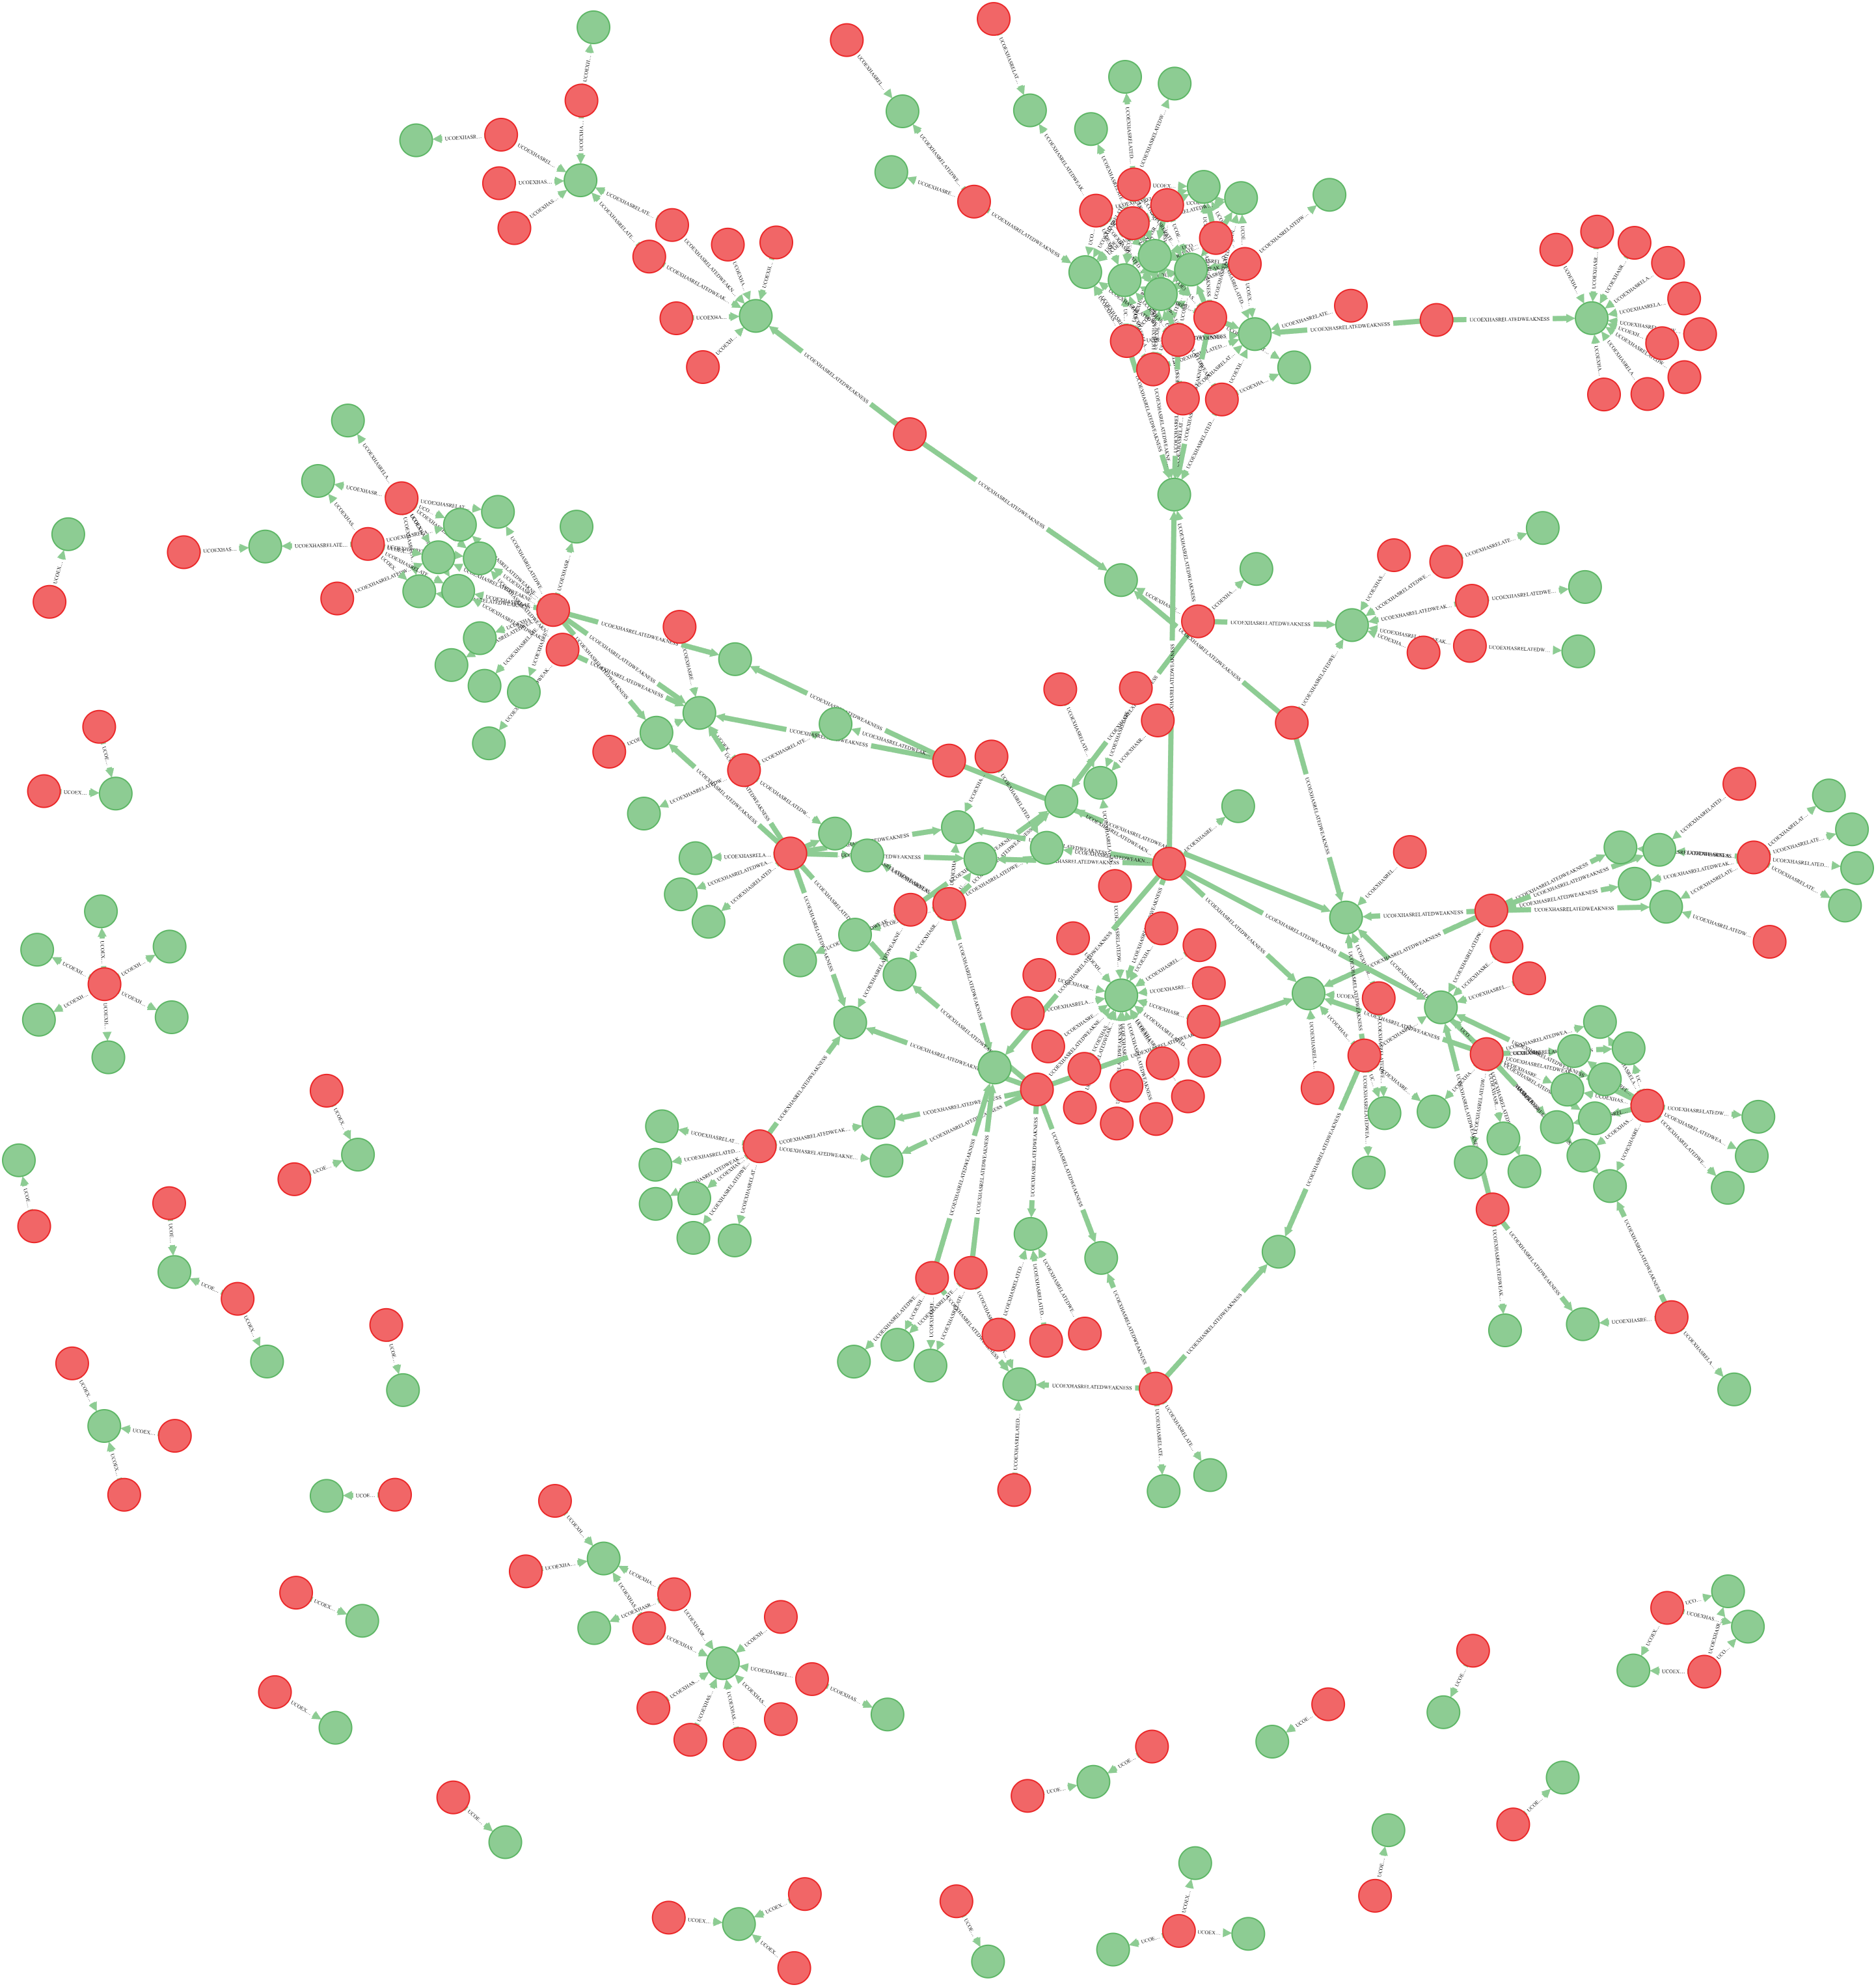

In [ ]:
query3 = """
    MATCH (c:UcoexCAPEC)-[r]->(p:Resource) RETURN c, type(r) AS Relationship, p
"""
params = {}
records = run_query(query3, parameters=params)
df3 = pd.DataFrame(records)
df3

,c,Relationship,p
0,{'uri': 'http://example.com/ucoex#CAPEC-2'},UCOEXHASTAXONOMYMAPPING,{'uri': 'http://example.com/ucoex#1531'}
1,{'uri': 'http://example.com/ucoex#CAPEC-2'},UCOEXHASRELATEDWEAKNESS,{'ucocommonConsequences': ['b'<ns0:Common_Cons...
2,{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASRELATEDWEAKNESS,{'ucocommonConsequences': ['b'<ns0:Common_Cons...
3,{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASRELATEDWEAKNESS,{'ucocommonConsequences': ['b'<ns0:Common_Cons...
4,{'uri': 'http://example.com/ucoex#CAPEC-1'},UCOEXHASRELATEDWEAKNESS,{'ucocommonConsequences': ['b'<ns0:Common_Cons...
...,...,...,...
662,{'uri': 'http://example.com/ucoex#CAPEC-300'},UCOEXHASRELATEDWEAKNESS,{'ucocommonConsequences': ['b'<ns0:Common_Cons...
663,{'uri': 'http://example.com/ucoex#CAPEC-309'},UCOEXHASTAXONOMYMAPPING,{'uri': 'http://example.com/ucoex#1016'}
664,{'uri': 'http://example.com/ucoex#CAPEC-309'},UCOEXHASRELATEDWEAKNESS,{'ucocommonConsequences': ['b'<ns0:Common_Cons...
665,{'uri': 'http://example.com/ucoex#CAPEC-309'},UCOEXHASTAXONOMYMAPPING,{'uri': 'http://example.com/ucoex#1590'}


![CAPEC to other node.png](<attachment:CAPEC to other node.png>)
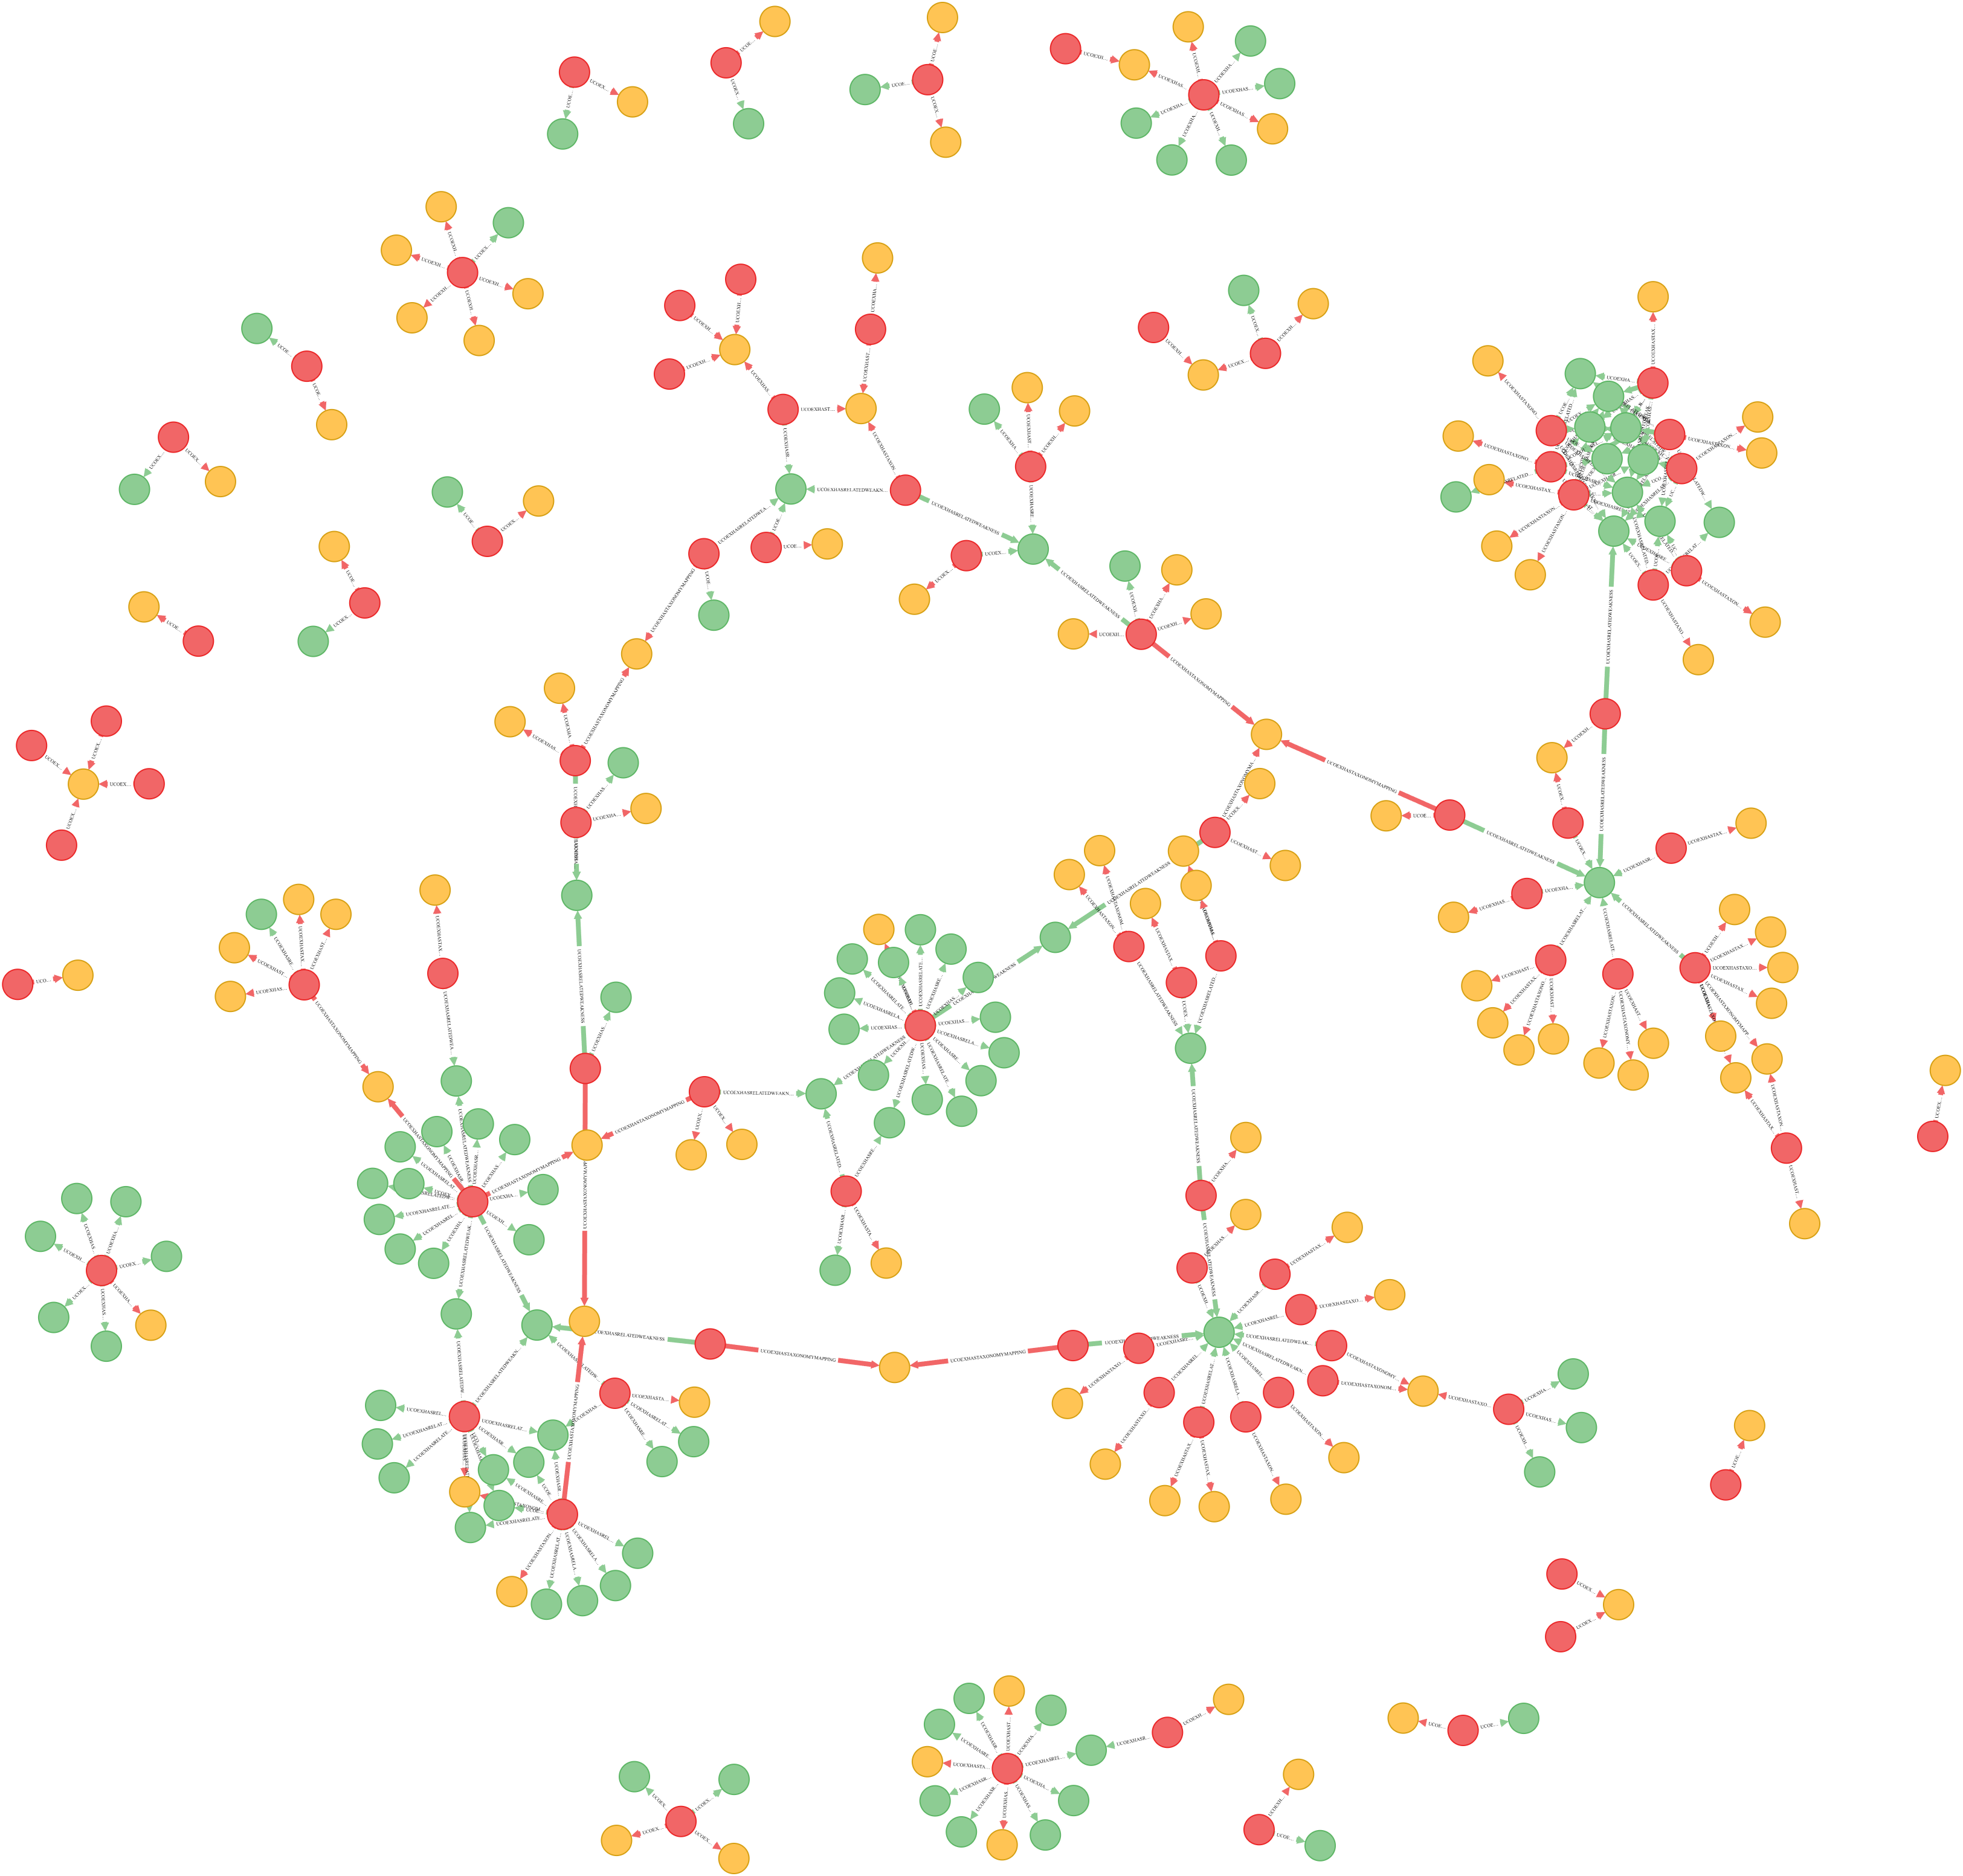

In [ ]:
# As suspected, the connection between parent and children in UcoexCAPEC has none
query4 = """
    MATCH (c:UcoexCAPEC)-[r]->(p:UcoexCAPEC) RETURN c, type(r) AS Relationship, p
"""
params = {}
records = run_query(query4, parameters=params)
df4 = pd.DataFrame(records)
df4

""


## CAPEC Dataset Overview (Before Update)

Prior to the re-exploration process, the CAPEC dataset was structured with limited mapping based solely on the `Related_Attack_Patterns` field. Prior dataset used dataset `Att&CK Related Pattern` where it was an external mapping to `MITRE Att&CK` only, thus complete CAPCE dataset was missing. The prior dataset included:

- **177 CAPEC nodes** in the graph, each consisting of:
  - A unique `NodeId` (Neo4j internal node ID)
  - A label (All nodes as `Resources` and `UcoexCAPEC`)
  - A URI formatted as `example.com/ucoex#CAPEC-{ID}`

- **Mapped Relationships:**
  - **277** total links to MITRE ATT&CK Attack (Relationship: `UCOEXHASTAXONOMYMAPPING`)
  - **390** links to CWE entries (Relationship: `UCOEXHASRELATEDWEAKNESS`)

**Total relationships: 667**

## After Exploration and Modifies

The CAPEC dataset was restructured by shifting the focus to a more detailed using the **"Mechanism of Attack"** dataset as the core context. Then the transformation involved parsing and analyzing the full CAPEC dataset (`capec.json`) for deeper node property-level relationships and entity information.

### 🛠️ Key Updates in Data Integration

The Python script `capec_collection.py` was updated to:
- Parse and utilize the `"Mechanism of Attack"` to explore the full dataset structure.
- Traverse deeply nested fields for complete details

### Enhancement to RDF Mapping (TTL)

The `CAPEC.ttl` script was significantly modified to add comprehensive properties to each CAPEC node in Neo4j. Each new CAPEC node includes the following information:

- **id** — Neo4j node ID
- **CAPEC_ID** — Used as a reference back to the original CAPEC source
- **Name** — The title of the attack pattern
- **Abstraction Detail** — Indicates the abstraction level (e.g., Meta, Standard)
- **Description** — A textual explanation of the attack
- **Likelihood of Attack** — Qualitative assessment of attack probability
- **Severity** — Typical impact severity
- **Related Attack Patterns** — References to other CAPEC attack patterns (CAPEC → CAPEC)
- **Execution Flow (Techniques)** — A collection of techniques under execution steps
- **Prerequisites** — Conditions required prior to exploitation
- **Skills Required** — Level of expertise needed to execute the attack
- **Resources Required** — Necessary tools or system access for attack execution
- **Consequences** — Potential impact or damage of the attack
- **Mitigation Strategies** — Suggested controls or defensive techniques
- **Example Instances** — Real-world examples demonstrating the attack
- **Related Weaknesses** — Mapped CWE relationships (CAPEC → CWE)

In [2]:
query5 = """
    MATCH (c:UcoexCAPEC) RETURN count(c) AS Total_CAPEC_Node
"""
params = {}
records = run_query(query5, parameters=params)
df5 = pd.DataFrame(records)
df5

,Total_CAPEC_Node
0,559


In [3]:
query5_5 = """
MATCH (c:UcoexCAPEC)
UNWIND keys(c) AS propertyKey
RETURN DISTINCT propertyKey
LIMIT 30
"""
params = {}
records = run_query(query5_5, parameters=params)
df5_5 = pd.DataFrame(records)
df5_5

,propertyKey
0,ucoexDescription
1,ucoexRelatedAttPattern
2,ucoexMitigations
3,ucoexSkills_Required
4,ucoexPrerequisites
5,uri
6,ucoexAbstraction
7,ucoexSeverity
8,ucoexLikelihood
9,label


#### These are the 18 unique properties in **UcoexCAPEC** nodes in the knowledge graph:

Identification & Labels
- **ucoexCAPEC_id** – CAPEC_Id -Ex: "50"
- **ucoexCAPEC_name** – Name of the attack pattern
- **uri** – Unique resource identifier links to source
- **label** – Node label. Ex: CAPEC-{ID} - {Name}

Descriptions & Context
- **ucoexDescription** – Description
- **ucoexExtendedDescription** – Detailed Further Explanation
- **ucoexExample** – Example scenarios
- **ucoexAbstraction** – Abstraction level (e.g., Meta, Standard)

Relationships
- **ucoexRelatedWeaknesses** – Links to CWE weaknesses
- **ucoexRelatedAttPattern** – Related CAPEC patterns
- **ucoexTaxonomyMappingATT&CK** – Mapped MITRE ATT&CK techniques

Attack Details
- **ucoexPrerequisites** – Required conditions before attack
- **ucoexResources_Required** - Required Resources before attack
- **ucoexSkills_Required** – Skills needed to perform the attack
- **ucoexConsequences** – Potential impact through SCOPE and IMPACT
- **ucoexExecutionFlowTechnique** – Execution techniques used into Step, Phase, Descriptions, Techniques

Assessment
- **ucoexSeverity** – Severity rating
- **ucoexLikelihood** – Likelihood of occurrence

Defensive Information
- **ucoexMitigations** – Suggested mitigations

#### This Cypher Query below is for fetching the Entire CAPEC Collection from Neo4j

In [26]:
query6 = """
MATCH (c:UcoexCAPEC)
RETURN 
    c.ucoexCAPEC_id AS CAPEC_ID, 
    c.ucoexCAPEC_name,
    c.label AS CAPEC_ID_Name,
    c.ucoexAbstraction, 
    c.ucoexDescription, 
    c.ucoexLikelihood, 
    c.ucoexSeverity, 
    apoc.text.join(c.ucoexExtendedDescription, ", ") AS Extended_Description,
    apoc.text.join(c.ucoexRelatedAttPattern, ", ") AS Related_Att_Pattern_CAPEC, 
    apoc.text.join(c.ucoexExecutionFlowTechnique, ", ") AS Execution_Flow, 
    apoc.text.join(c.ucoexPrerequisites, ", ") AS Prerequisites,
    apoc.text.join(c.ucoexSkills_Required, ", ") AS Skills_Required,
    apoc.text.join(c.ucoexResources_Required, ", ") AS Resources_Required,
    apoc.text.join(c.ucoexConsequences, ", ") AS Consequences,
    apoc.text.join(c.ucoexMitigations, ", ") AS Mitigations,
    apoc.text.join(c.ucoexExample, ", ") AS Example_case,
    apoc.text.join(c.ucoexRelatedWeaknesses, ", ") AS Related_Weaknesses_to_CWE,
    apoc.text.join(c.`ucoexTaxonomyMappingATT&CK`, ", ") AS TaxonomyMapping_to_MITRE_ATT_CK,
    c.uri AS Reference_URI
ORDER BY toInteger(c.ucoexCAPEC_id)
"""
params = {}
records = run_query(query6, parameters=params)
df6 = pd.DataFrame(records)
df6

,CAPEC_ID,c.ucoexCAPEC_name,CAPEC_ID_Name,c.ucoexAbstraction,c.ucoexDescription,c.ucoexLikelihood,c.ucoexSeverity,Extended_Description,Related_Att_Pattern_CAPEC,Execution_Flow,Prerequisites,Skills_Required,Resources_Required,Consequences,Mitigations,Example_case,Related_Weaknesses_to_CWE,TaxonomyMapping_to_MITRE_ATT_CK,Reference_URI
0,1,Accessing Functionality Not Properly Constrain...,CAPEC-1: Accessing Functionality Not Properly ...,Standard,"In applications, particularly web applications...",High,High,None,"CanPrecede CAPEC-17, ChildOf CAPEC-122",STEP-3 (Experiment): [Iterate over access capa...,"The various resources, or individual URLs, mus...",Level:Low - Description:In order to discover u...,None,"SCOPE:Confidentiality,Access Control,Authoriza...",\n,Implementing the Model-View-Controller (MVC) w...,"CWE-1320, CWE-1321, CWE-434, CWE-1311, CWE-732...",T1574.010,https://capec.mitre.org/data/definitions/1.html
1,2,Inducing Account Lockout,CAPEC-2: Inducing Account Lockout,Standard,An attacker leverages the security functionali...,High,Medium,None,ChildOf CAPEC-212,STEP-2 (Experiment): [Obtain list of user acco...,An attacker must be able to reproduce behavior...,Level:Low - Description:No programming skills ...,None,SCOPE:Availability - IMPACT:Resource Consumption,Implement intelligent password throttling mech...,A famous example of this type an attack is the...,CWE-645,T1531,https://capec.mitre.org/data/definitions/2.html
2,3,Using Leading 'Ghost' Character Sequences to B...,CAPEC-3: Using Leading 'Ghost' Character Seque...,Detailed,Some APIs will strip certain leading character...,Medium,Medium,None,ChildOf CAPEC-267,STEP-3 (Exploit): [Bypass input filtering] Usi...,The targeted API must ignore the leading ghost...,Level:Medium - Description:The ability to make...,None,"SCOPE:Integrity - IMPACT:Modify Data, SCOPE:Co...",Use an allowlist rather than a denylist input ...,Alternate Encoding with Ghost Characters in FT...,"CWE-697, CWE-20, CWE-180, CWE-181, CWE-41, CWE...",None,https://capec.mitre.org/data/definitions/3.html
3,4,Using Alternative IP Address Encodings,CAPEC-4: Using Alternative IP Address Encodings,Detailed,This attack relies on the adversary using unex...,Medium,High,None,ChildOf CAPEC-267,STEP-2 (Experiment): [Probe entry points to lo...,The adversary must have the ability to communi...,Level:Low - Description:The adversary has only...,None,"SCOPE:Confidentiality,Access Control,Authoriza...","Design: Default deny access control policies, ...",An adversary identifies an application server ...,"CWE-291, CWE-173",None,https://capec.mitre.org/data/definitions/4.html
4,5,Blue Boxing,CAPEC-5: Blue Boxing,Detailed,This type of attack against older telephone sw...,Medium,Very High,None,ChildOf CAPEC-220,None,System must use weak authentication mechanisms...,Level:Low - Description:Given a vulnerable pho...,None,"SCOPE:Confidentiality,Access Control,Authoriza...",Use strong access control such as two factor a...,An adversary identifies a vulnerable CCITT-5 p...,CWE-285,None,https://capec.mitre.org/data/definitions/5.html
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554,698,Install Malicious Extension,CAPEC-698: Install Malicious Extension,Detailed,An adversary directly installs or tricks a use...,Medium,High,Many software applications allow users to inst...,ChildOf CAPEC-542,STEP-3 (Exploit): [Install malicious extension...,The adversary must craft malware based on the ...,Level:Medium - Description:Ability to create m...,None,"SCOPE:Authorization,Access Control - IMPACT:Ex...",Confirm extensions/plugins are legitimate and ...,"In December 2018, it was reported that North K...","CWE-507, CWE-829","T1505.004, T1176",https://capec.mitre.org/data/definitions/698.html
555,699,Eavesdropping on a Monitor,CAPEC-699: Eavesdropping on a Monitor,Meta,An Adversary can eavesdrop on the content of a...,Medium,High,"From the victim’s point of view, this specifie...",ChildOf CAPEC-651,STEP-2 (Exp

In [28]:
CAPEC_ID_list = df6['CAPEC_ID_Name'].tolist()
CAPEC_ID_list

['CAPEC-1: Accessing Functionality Not Properly Constrained by ACLs',
 'CAPEC-2: Inducing Account Lockout',
 "CAPEC-3: Using Leading 'Ghost' Character Sequences to Bypass Input Filters",
 'CAPEC-4: Using Alternative IP Address Encodings',
 'CAPEC-5: Blue Boxing',
 'CAPEC-6: Argument Injection',
 'CAPEC-7: Blind SQL Injection',
 'CAPEC-8: Buffer Overflow in an API Call',
 'CAPEC-9: Buffer Overflow in Local Command-Line Utilities',
 'CAPEC-10: Buffer Overflow via Environment Variables',
 'CAPEC-11: Cause Web Server Misclassification',
 'CAPEC-12: Choosing Message Identifier',
 'CAPEC-13: Subverting Environment Variable Values',
 'CAPEC-14: Client-side Injection-induced Buffer Overflow',
 'CAPEC-15: Command Delimiters',
 'CAPEC-16: Dictionary-based Password Attack',
 'CAPEC-17: Using Malicious Files',
 'CAPEC-18: XSS Targeting Non-Script Elements',
 'CAPEC-19: Embedding Scripts within Scripts',
 'CAPEC-20: Encryption Brute Forcing',
 'CAPEC-21: Exploitation of Trusted Identifiers',
 'CAPE

In [34]:
query10_1 = """
MATCH (c:UcoexCAPEC)
RETURN
  CASE 
    WHEN c.ucoexLikelihood IS NULL 
      OR c.ucoexLikelihood = '' 
    THEN 'Null' 
    ELSE c.ucoexLikelihood 
  END AS Likelihood,
  count(*) AS Count
ORDER BY Count;
"""
params = {}
records = run_query(query10_1, parameters=params)
df10_1 = pd.DataFrame(records)
df10_1

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: } {title: This feature is deprecated and will be removed in future versions.} {description: Aggregation column contains implicit grouping expressions. Aggregation expressions with implicit grouping keys are deprecated and will be removed in a future version. For example, in 'RETURN n.a, n.a + n.b + count(*)' the aggregation expression 'n.a + n.b + count(*)' includes the implicit grouping key 'n.b', and this expression is now deprecated. It may be possible to rewrite the query by extracting these grouping/aggregation expressions into a preceding WITH clause.} {position: line: 11, column: 10, offset: 201} for query: "\nMATCH (c:UcoexCAPEC)\nRETURN\n  CASE \n    WHEN c.ucoexLikelihood IS NULL \n      OR c.ucoexLikelihood = '' \n    THEN 'Null' \n    ELSE c.ucoexLikelihood \n  END AS Likelihood,\n  count(*) AS Count\nORDER BY Count;\n"


,Likelihood,Count
0,Low,96
1,Medium,118
2,High,131
3,Null,214


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11952\1371389871.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df10_1, x='Likelihood', y='Count', palette='viridis')


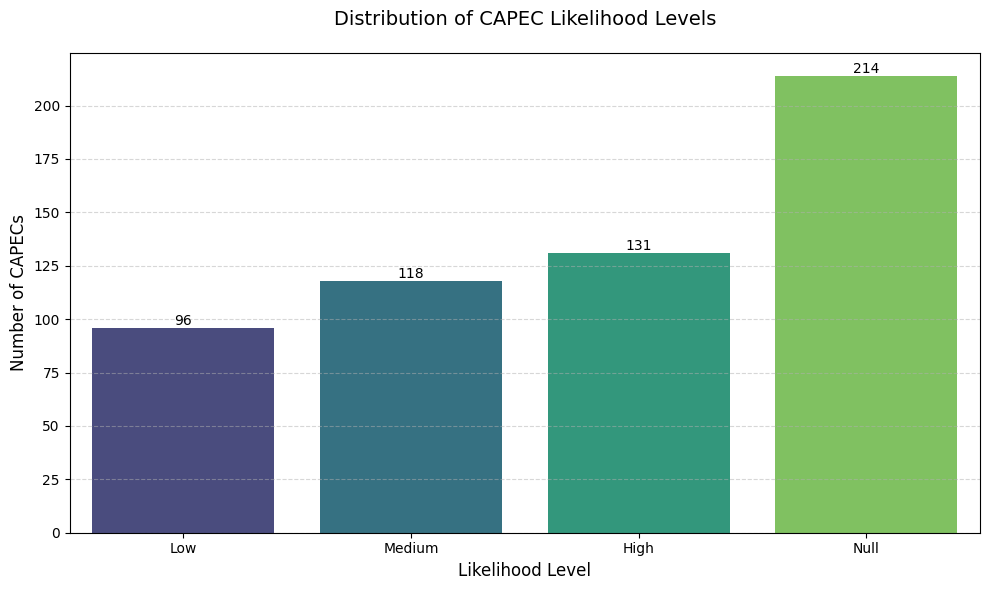

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df10_1, x='Likelihood', y='Count', palette='viridis')

# Customize the plot
plt.title('Distribution of CAPEC Likelihood Levels', fontsize=14, pad=20)
plt.xlabel('Likelihood Level', fontsize=12)
plt.ylabel('Number of CAPECs', fontsize=12)

# Add value labels on top of each bar
for i, v in enumerate(df10_1['Count']):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.xticks(rotation=0)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [68]:
query10_2 = """
MATCH (c:UcoexCAPEC)
RETURN
  CASE 
    WHEN c.ucoexSeverity IS NULL 
      OR c.ucoexSeverity = '' 
    THEN 'Null' 
    ELSE c.ucoexSeverity
  END AS Severity,
  count(*) AS Count
"""
params = {}
records = run_query(query10_2, parameters=params)
df10_2 = pd.DataFrame(records)
df10_2

,Severity,Count
0,High,211
1,Medium,112
2,Low,103
3,Null,70
4,Very High,59
5,Very Low,4


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11952\3728527710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


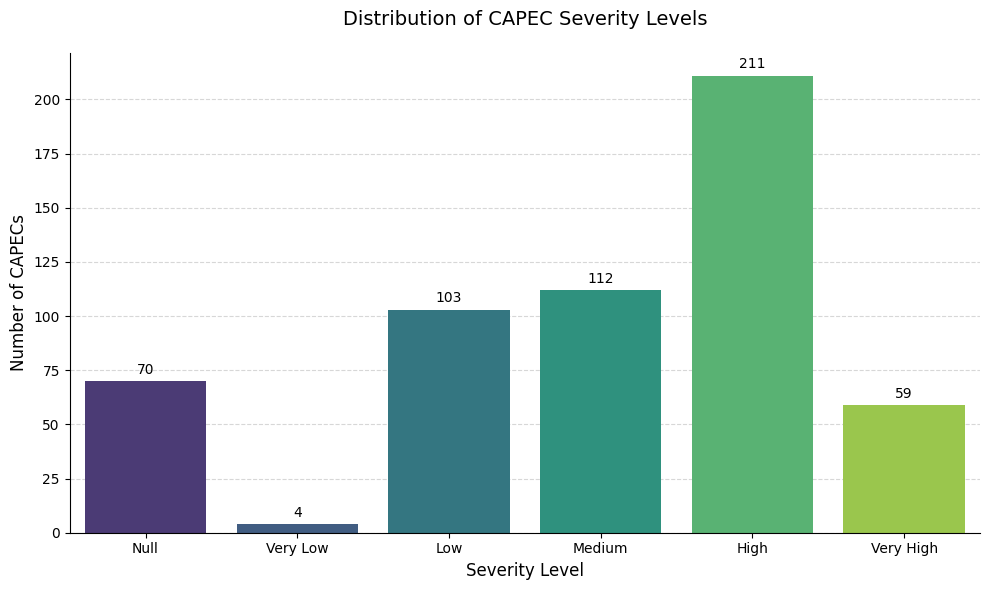

In [72]:
order = ['Null','Very Low','Low','Medium','High','Very High']

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df10_2,
    x='Severity',
    y='Count',
    order=order,
    palette='viridis'
)

sns.despine(ax=ax)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Titles and labels
ax.set_title('Distribution of CAPEC Severity Levels', fontsize=14, pad=20)
ax.set_xlabel('Severity Level', fontsize=12)
ax.set_ylabel('Number of CAPECs', fontsize=12)

# Annotate bars with integer labels
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(
        str(height),
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [46]:
df_scope = df6['Consequences'] \
    .str.extract(r'SCOPE:(.*?)\s*-\s*IMPACT', expand=False) \
    .rename('Scope')
df_scope

0       Confidentiality,Access Control,Authorization
1                                       Availability
2                                          Integrity
3       Confidentiality,Access Control,Authorization
4       Confidentiality,Access Control,Authorization
                           ...                      
554                     Authorization,Access Control
555                                  Confidentiality
556                          Integrity,Authorization
557    Confidentiality,Access Control,Authentication
558                                  Confidentiality
Name: Scope, Length: 559, dtype: object

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11952\2566327772.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='Scope', y='Count', palette='viridis',order=counts['Scope'] )


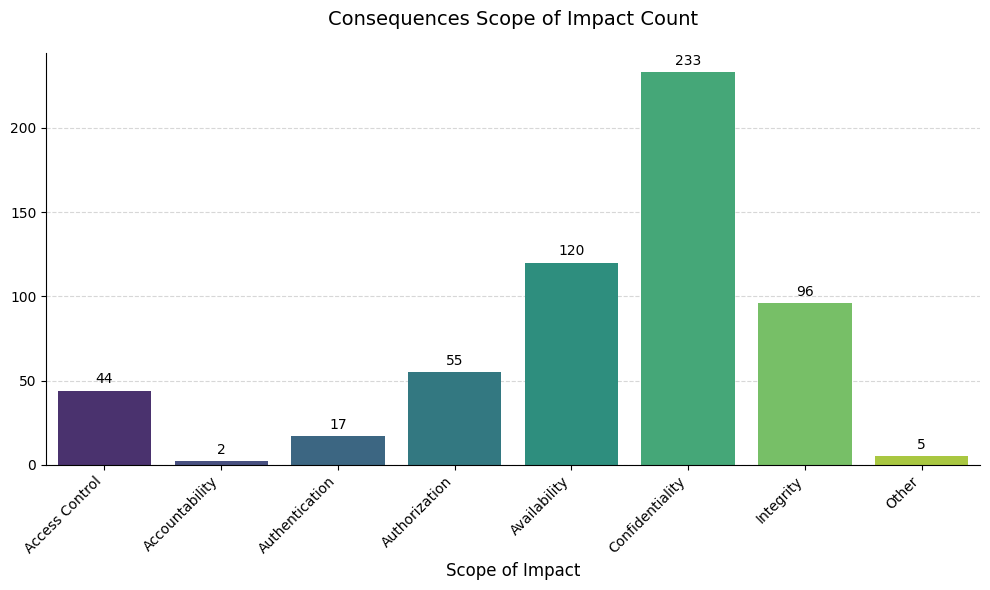

In [58]:
counts = (
    df_scope
      .dropna()
      .str.split(',')
      .explode()
      .str.strip()
      .value_counts()
      .reset_index()
)
counts.columns = ['Scope', 'Count']
counts = counts.sort_values('Scope')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=counts, x='Scope', y='Count', palette='viridis',order=counts['Scope'] )

sns.despine(ax=ax)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Titles and labels
ax.set_title('Consequences Scope of Impact Count', fontsize=14, pad=20)
ax.set_xlabel('Scope of Impact', fontsize=12)
ax.set_ylabel('', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}', 
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        xytext=(0, 3), textcoords='offset points'
    )

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Relationship to other Datasets

In [15]:
query7 = """
MATCH (c:UcoexCAPEC)-[rel:UCOEXHASRELATEDWEAKNESS]->(p:Resource) RETURN rel AS Relationship, p AS Node_Details
"""
params = {}
records = run_query(query7, parameters=params)
df7 = pd.DataFrame(records)
df7

,Relationship,Node_Details
0,"({}, UCOEXHASRELATEDWEAKNESS, {'ucoreferences'...","{'ucoreferences': '{reference=[{""External_Refe..."
1,"({}, UCOEXHASRELATEDWEAKNESS, {'ucostructure':...","{'ucostructure': 'Simple', 'ucomodesOfIntroduc..."
2,"({}, UCOEXHASRELATEDWEAKNESS, {'ucoreferences'...","{'ucoreferences': '{reference=[{""External_Refe..."
3,"({}, UCOEXHASRELATEDWEAKNESS, {'ucoreferences'...","{'ucoreferences': '{reference=[{""External_Refe..."
4,"({}, UCOEXHASRELATEDWEAKNESS, {'ucoreferences'...","{'ucoreferences': '{reference=[{""External_Refe..."
...,...,...
1207,"({}, UCOEXHASRELATEDWEAKNESS, {'ucoreferences'...","{'ucoreferences': '{reference=[{""External_Refe..."
1208,"({}, UCOEXHASRELATEDWEAKNESS, {'ucostructure':...","{'ucostructure': 'Simple', 'ucomodesOfIntroduc..."
1209,"({}, UCOEXHASRELATEDWEAKNESS, {'ucostructure':...","{'ucostructure': 'Chain', 'ucocweName': 'Integ..."
1210,"({}, UCOEXHASRELATEDWEAKNESS, {'ucoreferences'...","{'ucoreferences': '{reference=[{""External_Refe..."


In [16]:
query8 = """
MATCH (c:UcoexCAPEC)-[rel:UCOEXHASTAXONOMYMAPPING]->(p:Resource) RETURN rel AS Relationship, p AS Node_Details
"""
params = {}
records = run_query(query8, parameters=params)
df8 = pd.DataFrame(records)
df8

,Relationship,Node_Details
0,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1498.001'}
1,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1499.001'}
2,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1036.005'}
3,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1056'}
4,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1090.004'}
...,...,...
266,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1513'}
267,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1113'}
268,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1552.001'}
269,"({}, UCOEXHASTAXONOMYMAPPING, {'uri': 'http://...",{'uri': 'http://example.com/ucoex#T1195'}


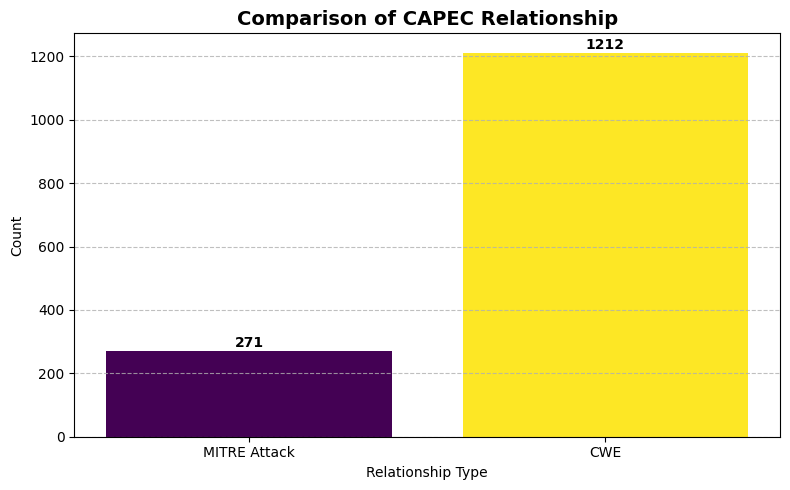

In [60]:
import numpy as np
# Count the number of relationships in each dataframe
taxonomy_count = len(df8)
weakness_count = len(df7)

# Prepare data for plotting
data = {
    'Relationship Type': ['MITRE Attack', 'CWE'],
    'Count': [taxonomy_count, weakness_count]
}

# Convert to DataFrame
df_plot = pd.DataFrame(data)
n = len(df_plot)
colors = plt.cm.viridis(np.linspace(0, 1, n))

# Plotting
plt.figure(figsize=(8, 5))
bars = plt.bar(df_plot['Relationship Type'], df_plot['Count'], color=colors)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 2, str(height), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Comparison of CAPEC Relationship', fontsize=14, fontweight='bold')
plt.xlabel('Relationship Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

### Isolated Node of CAPEC

Some CAPEC nodes appear isolated—without any relationships—due to a few key reasons:

- Missing or incomplete data in the CAPEC JSON (e.g., no listed weaknesses or attack patterns)
- Unmapped or niche patterns, like physical or domain-specific attacks (e.g., Voice Phishing, Smudge Attack)
- Abstract or foundational patterns that don’t directly relate to other datasets

These nodes are not necessarily errors but reflect either gaps in data or patterns that stand alone in nature.

In [61]:
query9 = """
MATCH (n:UcoexCAPEC)
WHERE NOT EXISTS {
  MATCH (n)--()
}
RETURN count(n) AS Isolated_CAPEC_Count
"""
params = {}
records9 = run_query(query9, parameters=params)
records9

[{'Isolated_CAPEC_Count': 75}]

In [62]:
query10 = """
MATCH (n:UcoexCAPEC)
WHERE NOT EXISTS {
  MATCH (n)--()
}
RETURN n.ucoexCAPEC_id AS Isolated_CAPEC_ID, n.ucoexCAPEC_name AS Isolated_CAPEC_Name
"""
params = {}
records = run_query(query10, parameters=params)
df10 = pd.DataFrame(records)
df10

,Isolated_CAPEC_ID,Isolated_CAPEC_Name
0,519,Documentation Alteration to Cause Errors in Sy...
1,406,Dumpster Diving
2,447,Design Alteration
3,544,Counterfeit Organizations
4,521,Hardware Design Specifications Are Altered
...,...,...
70,547,Physical Destruction of Device or Component
71,390,Bypassing Physical Security
72,507,Physical Theft
73,429,Target Influence via Eye Cues


## Comparison Before and After Re-exploration of CAPEC

In [ ]:
set1 = set(df['CAPEC_ID'])        # The CAPEC list before
set2 = set(CAPEC_ID_list)         # The CAPEC list after

# Get the differences
diff_list = list(set1 - set2)
print(diff_list)

NameError: name 'df' is not defined

### CAPEC Dataset Comparison: Before vs After Re-exploration
#### Before Update

The initial version of the CAPEC dataset was limited in scope and representation:

- CAPEC Nodes: *177*
- Relationship Coverage:
  - MITRE ATT&CK (UCOEXHASTAXONOMYMAPPING): *277*
  - CWE/Weaknesses (UCOEXHASRELATEDWEAKNESS): *390*

**Total Relationships: 667**

**Isolated Nodes: Not tracked**

**Node Properties: Minimal — only included Neo4j NodeId, label, and a basic URI (example.com/ucoex#CAPEC-{ID})**

The previous dataset relied solely on externally mapped Related_Attack_Patterns, omitting large portions of the CAPEC collection.

#### After Update

The revised dataset now reflects a more comprehensive and semantically rich structure:

- CAPEC Nodes: *559*
- Relationship Coverage:
  - MITRE ATT&CK (UCOEXHASTAXONOMYMAPPING): *271*
  - CWE/Weaknesses (UCOEXHASRELATEDWEAKNESS): *1212*

**Total Relationships: 1,483**

**Isolated Nodes: 75 CAPEC nodes have no relationships**

**Node Properties Enhanced:**

1. ucoexRelatedAttPattern
2. ucoexMitigations
3. ucoexSkills_Required
4. ucoexPrerequisites
5. uri
6. ucoexAbstraction
7. ucoexSeverity
8. ucoexLikelihood
9. label
10. ucoexCAPEC_name
11. ucoexCAPEC_id
12. ucoexExample
13. ucoexRelatedWeaknesses
14. ucoexExecutionFlowTechnique
15. ucoexConsequences
16. ucoexTaxonomyMappingATT&CK
17. ucoexExtendedDescription
18. ucoexResources_Required

#### Summary of Improvements

| Metric                        | Before        | After        | Change   |
|------------------------------|---------------|--------------|----------|
| CAPEC Nodes                  | 177           | 559          | +382     |
| MITRE ATT&CK Relationships   | 277           | 271          | -6       |
| CWE Relationships            | 390           | 1212         | +822     |
| Total Relationships          | 667           | 1483         | +816     |
| Isolated CAPEC Nodes         | Not available | 75           | -------- |
| Node Property Depth          | Minimal       | Fully Enriched | -------- |